# APRENDIZAJE NO SUPERVISADO
## CLUSTERITZACIÓN
### AGRUPAMIENTO PER DENSIDAD - DBSCAN

El conjunto de datos consta de 21613 observaciones y trata sobre la compraventa de viviendas en el condado de King (un condado del estado de Washington, en Estados Unidos), vendidas durante el período de un año, de mayo de 2014 a mayo de 2015.

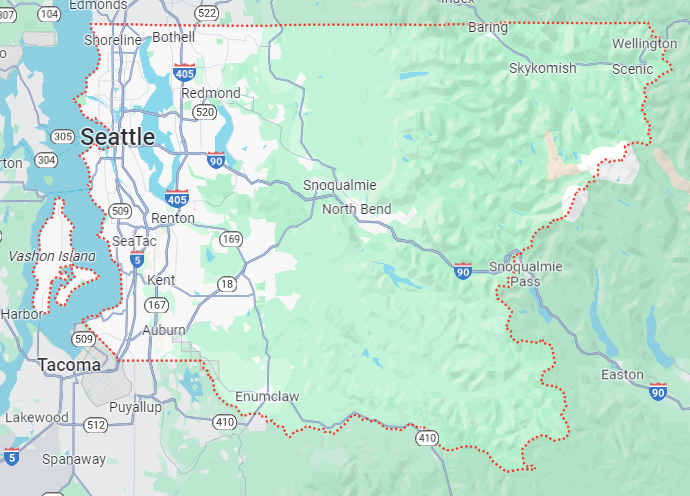

Las características son las siguientes:
* **Id**: identificador de cada casa vendida
* **Date**: fecha de la venta de la casa
* **price**: precio de venta de la casa
* **bedrooms**: número de dormitorios
* **bathrooms**: número de baños, donde `.5` indica un baño con inodoro pero sin ducha
* **sqft_living**: superficie interior habitable en pies cuadrados
* **sqft_lot**: superficie del terreno en pies cuadrados
* **floors**: número de plantas
* **waterfront**: indica si la casa tiene vista al agua o no
* **view**: etiquetas del 0 al 4 que indican la calidad de la vista de la casa
* **condition**: etiquetas del 1 al 5 que indican el estado de la casa
* **grade**: etiquetas del 1 al 13 que indican el nivel de calidad de la construcción y el diseño, donde 1 a 3 corresponde a nivel bajo, 7 a nivel medio y 11 a 13 a nivel alto
* **sqft_above**: superficie interior sobre el nivel del suelo en pies cuadrados
* **sqft_basement**: superficie interior bajo el nivel del suelo en pies cuadrados
* **yr_built**: año de construcción de la casa (entre 1900 y 2015)
* **yr_renovated**: año de la última renovación de la casa (entre 1934 y 2015)
* **zipcode**: código postal de la zona donde se encuentra la casa
* **lat**: latitud
* **long**: longitud
* **sqft_living15**: superficie interior habitable en pies cuadrados de las 15 casas más cercanas
* **sqft_lot15**: superficie del terreno en pies cuadrados de las 15 casas más cercanas

El objetivo es identificar las zonas donde se concentraron más ventas de viviendas durante ese período.

# Fase 1: Recopilación de los datos


In [1]:
# Importación de las bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples
from sklearn.decomposition import PCA
from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/house_data.csv'
df = pd.read_csv(ruta)

Mounted at /content/drive


# Fase 2. Exploración y preparación de los datos

In [3]:
# Información del dataset
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df_escalado = df[['long', 'lat']]
df_escalado = scaler.fit_transform(df_escalado)
df_escalado

array([[0.21760797, 0.57149751],
       [0.16611296, 0.90895931],
       [0.23754153, 0.93614283],
       ...,
       [0.18272425, 0.70532411],
       [0.37375415, 0.60897539],
       [0.18272425, 0.70484156]])

# Fase 3. División de los datos de entrenamiento y prueba
En aprendizaje no supervisado no existe esta fase.


# Fase 4. Entrenamiento del modelo y realización de predicciones y Fase 5. Validación del modelo y Fase 6 y Fase 7. Optimización del modelo y prueba del nuevo modelo

El análisis de distancias-k es una parte importante del proceso de configuración de los parámetros del algoritmo DBSCAN. Este análisis ayuda a determinar un valor adecuado para el parámetro eps, que define el radio máximo entre dos puntos para ser considerados dentro de la misma región de densidad. Es necesario experimentar con distintos valores de k y observar cómo cambia el comportamiento del conjunto de datos.

Silhouette Score con n_neighbors=30: 0.24105601528374793
Silhouette Score con n_neighbors=35: 0.022584692529319706
Silhouette Score con n_neighbors=40: 0.023763043615232845
Silhouette Score con n_neighbors=50: 0.03323067111020866
Silhouette Score con n_neighbors=60: -0.10462069090378799
Silhouette Score con n_neighbors=70: -0.10449661905416271
Silhouette Score con n_neighbors=80: -0.0070865023730238615
Silhouette Score con n_neighbors=90: -0.008665804764981052


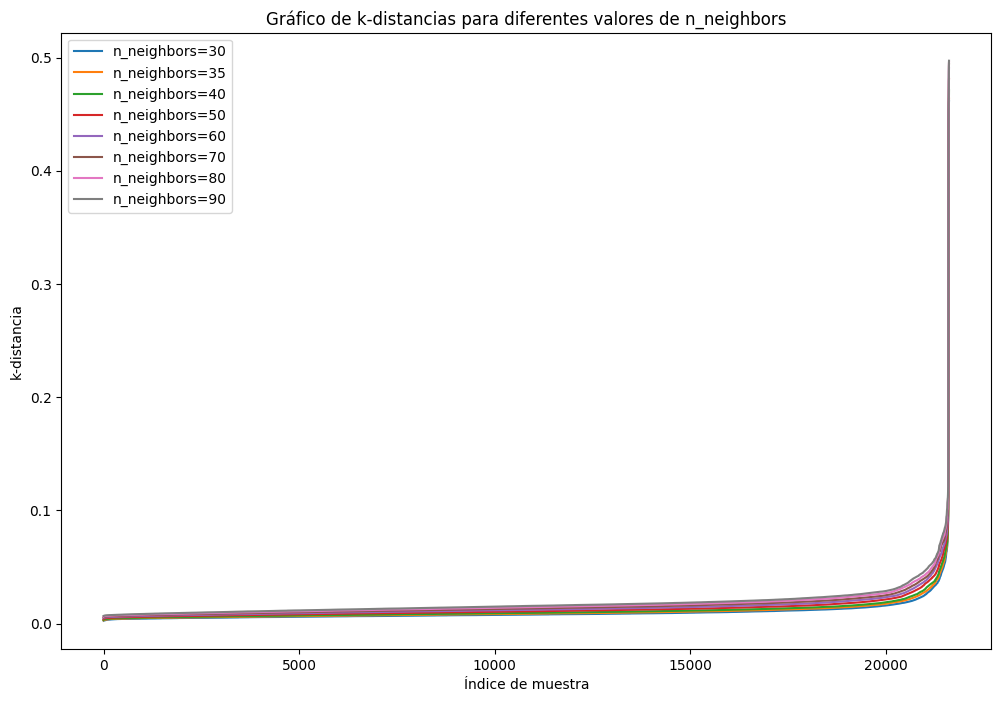

In [ ]:
# Prueba con diferentes valores de n_neighbors
valores_n_neighbors = [30, 35, 40, 50, 60, 70, 80, 90]

# Ajusta las dimensiones de la figura
plt.figure(figsize=(12, 8))

# Calcula el Silhouette Score para cada valor de n_neighbors
for n_neighbors in valores_n_neighbors:
    # Calcula las k-distancias
    knn = NearestNeighbors(n_neighbors=n_neighbors)
    knn.fit(df_escalado)
    distances, _ = knn.kneighbors(df_escalado)
    distances = np.sort(distances[:, -1])

    # Visualiza el gráfico de k-distancias para cada valor de n_neighbors
    plt.plot(distances, label=f'n_neighbors={n_neighbors}')

    # Aplica DBSCAN con el valor actual de n_neighbors
    dbscan = DBSCAN(eps=0.03, min_samples=n_neighbors)
    labels = dbscan.fit_predict(df_escalado)

    # Calcula el Silhouette Score
    silhouette_avg = silhouette_score(df_escalado, labels)
    print(f"Silhouette Score con n_neighbors={n_neighbors}: {silhouette_avg}")

# Muestra el gráfico con los distintos valores de n_neighbors
plt.xlabel('Índice de muestra')
plt.ylabel('k-distancia')
plt.title('Gráfico de k-distancias para diferentes valores de n_neighbors')
plt.legend()
plt.show()



Silhouette Score con n_neighbors=80: -0.0070865023730238615


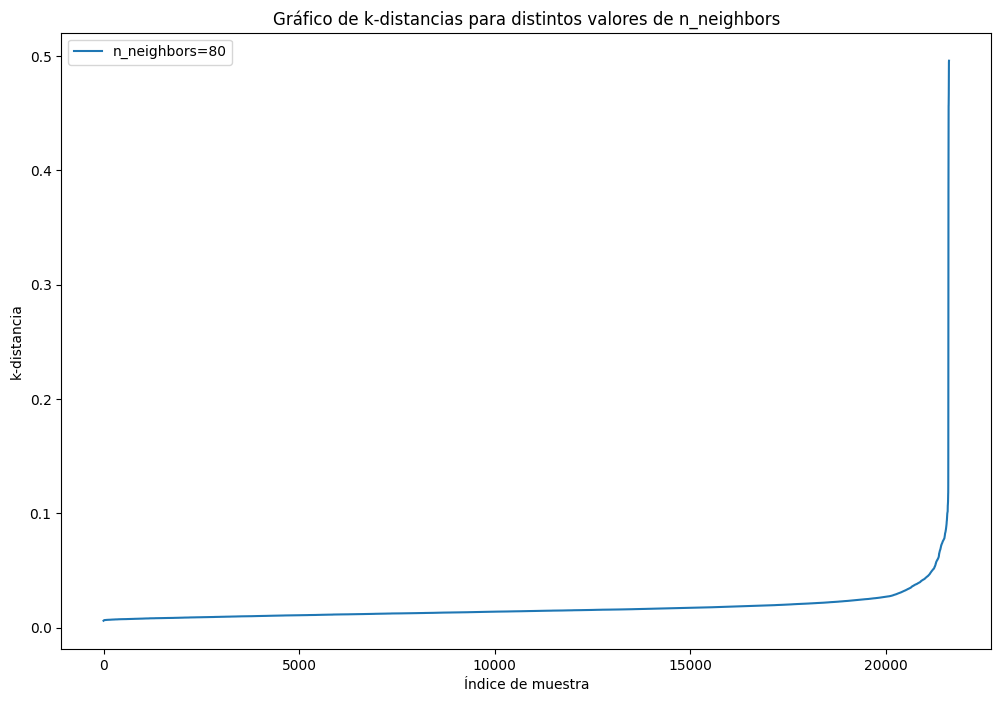

In [ ]:
# Prueba con distintos valores de n_neighbors
valores_n_neighbors = [80]

# Ajustar tamaño del gráfico
plt.figure(figsize=(12, 8))

# Calcular el Silhouette Score para cada valor de n_neighbors
for n_neighbors in valores_n_neighbors:
    # Calcular las k-distancias
    knn = NearestNeighbors(n_neighbors=n_neighbors)
    knn.fit(df_escalado)
    distances, _ = knn.kneighbors(df_escalado)
    distances = np.sort(distances[:, -1])

    # Mostrar el gráfico de k-distancias para cada valor
    plt.plot(distances, label=f'n_neighbors={n_neighbors}')

    # Aplicar DBSCAN con el valor actual de n_neighbors como min_samples
    dbscan = DBSCAN(eps=0.03, min_samples=n_neighbors)
    labels = dbscan.fit_predict(df_escalado)

    # Calcular el Silhouette Score
    silhouette_avg = silhouette_score(df_escalado, labels)
    print(f"Silhouette Score con n_neighbors={n_neighbors}: {silhouette_avg}")

# Mostrar el gráfico con todos los valores probados
plt.xlabel('Índice de muestra')
plt.ylabel('k-distancia')
plt.title('Gráfico de k-distancias para distintos valores de n_neighbors')
plt.legend()
plt.show()


In [ ]:
house_location = DBSCAN(eps=0.01, min_samples=20).fit(df_escalado)
labels_house_location = house_location.labels_
print('House location Labels:', sorted(set(int(label) for label in house_location.labels_)))

House location Labels: [-1, 0, 1]


<Axes: title={'left': 'Ubicación de les casas en el Condado de King'}, xlabel='long', ylabel='lat'>

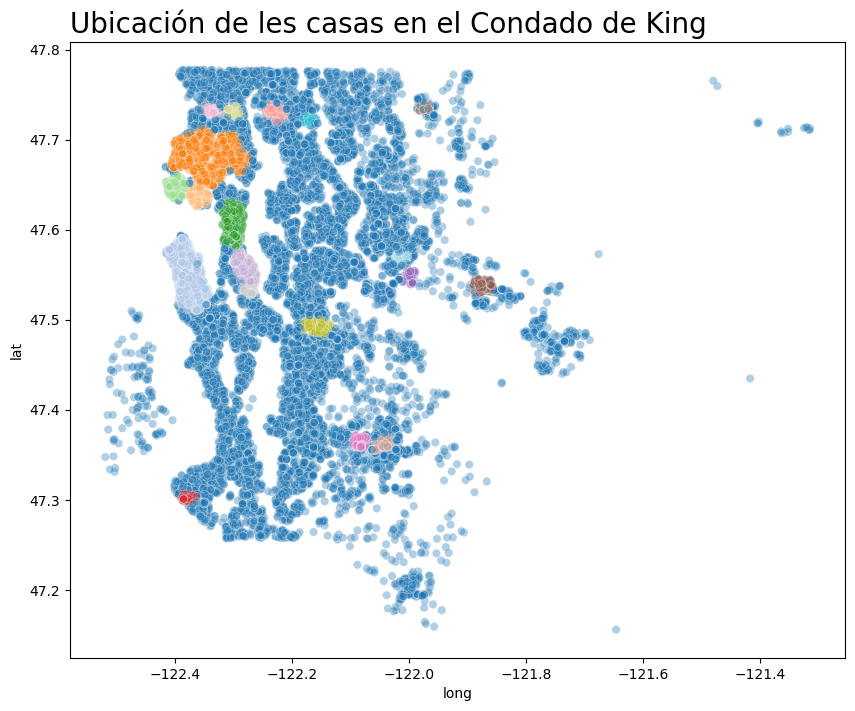

In [ ]:
# Visualización de los resultados con un diagrama de dispersión
fig = plt.figure(figsize=(10, 8))
plt.title('Ubicación de les casas en el Condado de King', loc='left', fontsize=20)
sns.scatterplot(x=df.long, y=df.lat, alpha=.35,
                hue=labels_house_location, palette="tab20", legend= None)

In [ ]:
# Eliminar el clúster -1 que corresponde a los outliers
df = df[house_location.labels_ != -1]

# También en los resultados
labels_house_location = labels_house_location[labels_house_location != -1]

<Axes: title={'left': 'Ubicación de les casas en el Condado de King'}, xlabel='long', ylabel='lat'>

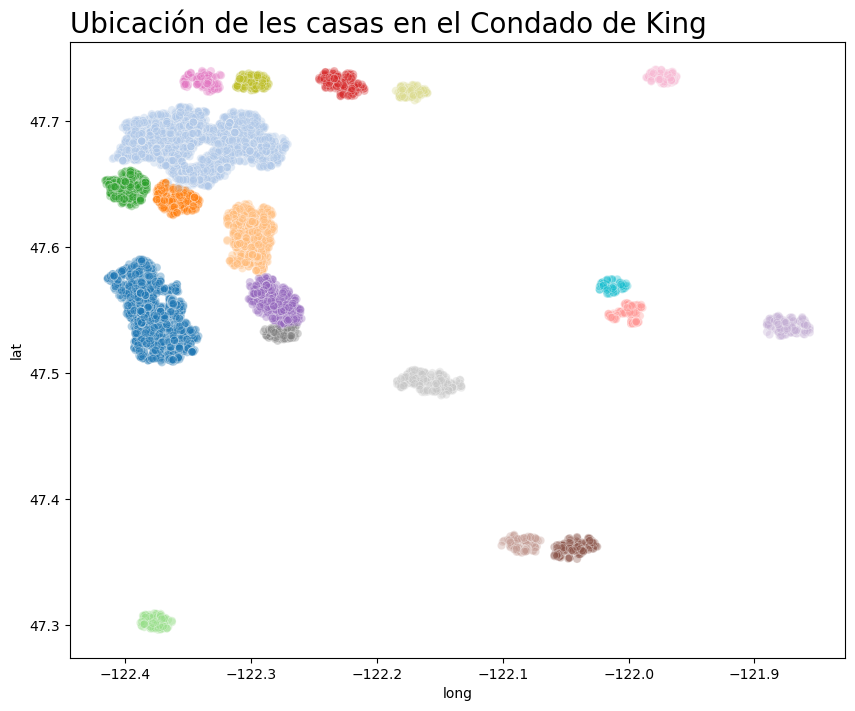

In [ ]:
fig = plt.figure(figsize=(10, 8))
plt.title('Ubicación de les casas en el Condado de King', loc='left', fontsize=20)
sns.scatterplot(x=df.long, y=df.lat, alpha=.35,
                hue=labels_house_location, palette="tab20", legend=None)


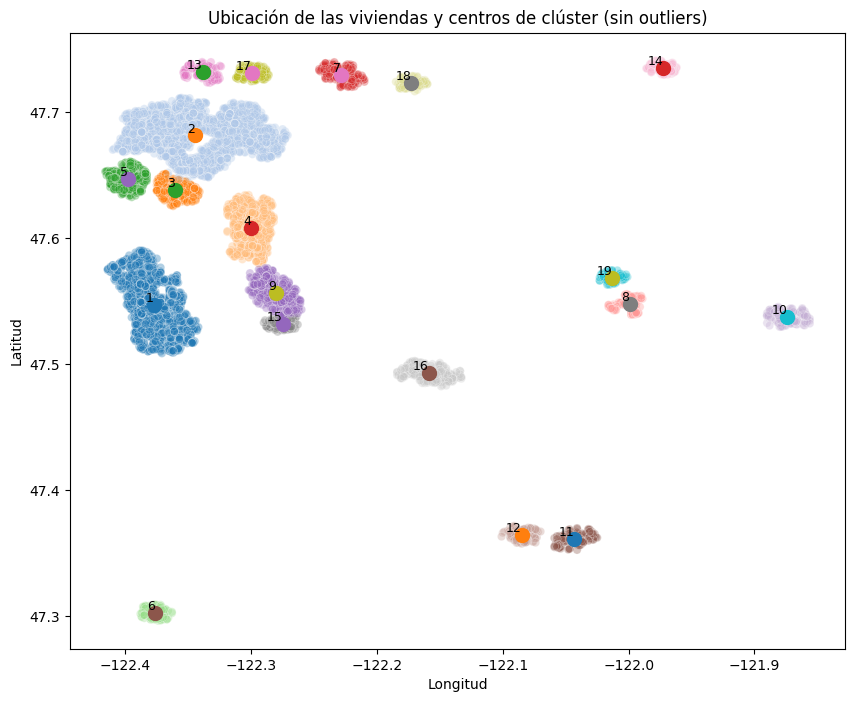

In [ ]:
from itertools import cycle

# Calcular los puntos centrales de los clústers después de filtrar los outliers
cluster_centers_list = []

for cluster_label in np.unique(labels_house_location):
    # Ignorar los puntos de ruido (-1)
    if cluster_label != -1:
        cluster_indices = np.where(labels_house_location == cluster_label)[0]
        cluster_center = np.mean(df.iloc[cluster_indices][['long', 'lat']], axis=0)
        cluster_centers_list.append(cluster_center)

# Convertir la lista de centros a un array de NumPy
cluster_centers_array = np.array(cluster_centers_list)

# Obtener una paleta de colores para los clústers
colors = cycle(plt.cm.tab10.colors)

# Crear una nueva figura
fig, ax = plt.subplots(figsize=(10, 8))

# Visualizar las casas como puntos coloreados según los clústers
sns.scatterplot(x=df.long, y=df.lat, alpha=0.35,
                hue=labels_house_location, palette="tab20", legend=None, ax=ax)

# Añadir los puntos centrales con número de clúster y colores distintos
for i, (lon, lat) in enumerate(cluster_centers_array):
    color = next(colors)
    ax.scatter(lon, lat, c=[color], marker='o', s=100)  # Ajustar tamaño (s) si se desea
    ax.text(lon, lat, f'{i + 1}', fontsize=9, ha='right', va='bottom')

# Etiquetas y título
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Ubicación de las viviendas y centros de clúster (sin outliers)')

# Mostrar el gráfico
plt.show()

In [ ]:
from geopy.geocoders import Nominatim
import folium
from folium import plugins

geolocator = Nominatim(user_agent="Seattle_explorer")
address = 'Seattle'
location = geolocator.geocode(address)
latitude = location.latitude
longitude = location.longitude

# Creación de un mapa interactivo con los puntos centrales de los clústeres
import folium
Seattle_map = folium.Map(location=[(latitude-0.15), (longitude+0.30)], zoom_start=10)

for index, location in enumerate(cluster_centers_array):
    folium.map.Marker(location=[location[1], location[0]],
                      icon=folium.plugins.BeautifyIcon(icon='plane', border_color='blue',
                                                       text_color='black',
                                                       background_color = 'yellow',
                                                       border_width = 2,
                                                       number=index,
                                                       icon_shape='marker')).add_to(Seattle_map)
# show map
Seattle_map

# Fase 8. Conclusiones


DBSCAN es otra técnica válida para realizar agrupamiento, al igual que las estudiadas anteriormente. Puede aplicarse sobre los mismos datos que K-means o el método aglomerativo, pero resulta más adecuada para problemas donde pueden existir clústers de forma irregular y para trabajar con datos espaciales, como la latitud y la longitud. Agrupa en función de la densidad, aunque la búsqueda del valor óptimo para algunos de sus hiperparámetros se base en la distancia euclidiana.